# Temporal Circuit Tracing

This notebook investigates whether short-term vs long-term temporal predictions use different circuits in Gemma 2 (2B). We use the circuit-tracer library to:

1. Run a prompt like "I will go to the gym " and examine logits for temporal tokens ("now", "today", "tomorrow", "later", "soon", "eventually")
2. Generate attribution graphs for the top short-term and long-term completions
3. Compare the circuits to see if they differ in substantial ways

In [1]:
import torch
import torch.nn.functional as F
from collections import namedtuple
from typing import List, Dict
from circuit_tracer import ReplacementModel, attribute
from circuit_tracer.graph import prune_graph
from graph_visualization import create_graph_visualization, Supernode, InterventionGraph, Feature
import matplotlib.pyplot as plt
import numpy as np

## 1. Load Model

In [2]:
backend = "transformerlens"
model = ReplacementModel.from_pretrained(
    "google/gemma-2-2b", "gemma",
    dtype=torch.bfloat16,
    backend=backend
)
print(f"Model loaded on {model.cfg.device}")

Fetching 26 files:   0%|          | 0/26 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

Loaded pretrained model google/gemma-2-2b into HookedTransformer
Model loaded on cuda


## 2. Examine Temporal Logits

Run the prompt and look at the probability distribution over temporal tokens.

In [3]:
prompt = "I will go to the gym "

# Get logits from the model
logits = model(prompt)
# Last token logits
last_logits = logits[0, -1, :]
probs = F.softmax(last_logits.float(), dim=-1)

# Temporal tokens to examine
temporal_tokens = {
    "short-term": ["now", "today", "tonight", "soon"],
    "long-term": ["tomorrow", "later", "eventually", "someday"],
    "other_temporal": ["after", "before", "next", "this"]
}

print(f"Prompt: '{prompt}'")
print(f"\n{'='*60}")
print(f"\nTop 20 predictions:")
top_probs, top_ids = probs.topk(20)
for i, (p, idx) in enumerate(zip(top_probs, top_ids)):
    token_str = model.tokenizer.decode(idx)
    print(f"  {i+1:2d}. {token_str!r:15s} {p.item():.4f}")

print(f"\n{'='*60}")
print(f"\nTemporal token probabilities:")
for category, tokens in temporal_tokens.items():
    print(f"\n  {category}:")
    for tok in tokens:
        token_ids = model.tokenizer.encode(tok, add_special_tokens=False)
        # Use the first token ID
        tid = token_ids[0]
        p = probs[tid].item()
        decoded = model.tokenizer.decode(tid)
        print(f"    {decoded!r:15s} (id={tid:6d})  prob={p:.6f}")

Prompt: 'I will go to the gym '


Top 20 predictions:
   1. '3'             0.2817
   2. '2'             0.1709
   3. '<strong>'      0.1036
   4. '4'             0.1036
   5. '5'             0.0915
   6. '1'             0.0629
   7. '<b>'           0.0555
   8. '6'             0.0297
   9. '7'             0.0180
  10. '<em>'          0.0180
  11. '<u>'           0.0140
  12. '<i>'           0.0096
  13. '\n\n'          0.0066
  14. '8'             0.0066
  15. '________________' 0.0052
  16. '9'             0.0040
  17. '\n'            0.0031
  18. '３'             0.0015
  19. '................' 0.0013
  20. '<code>'        0.0013


Temporal token probabilities:

  short-term:
    'now'           (id=  1032)  prob=0.000000
    'today'         (id= 23857)  prob=0.000000
    'ton'           (id=  1166)  prob=0.000000
    'soon'          (id= 81158)  prob=0.000000

  long-term:
    'tomorrow'      (id=122610)  prob=0.000001
    'later'         (id= 20427)  prob=0.000000
    'eventually' 

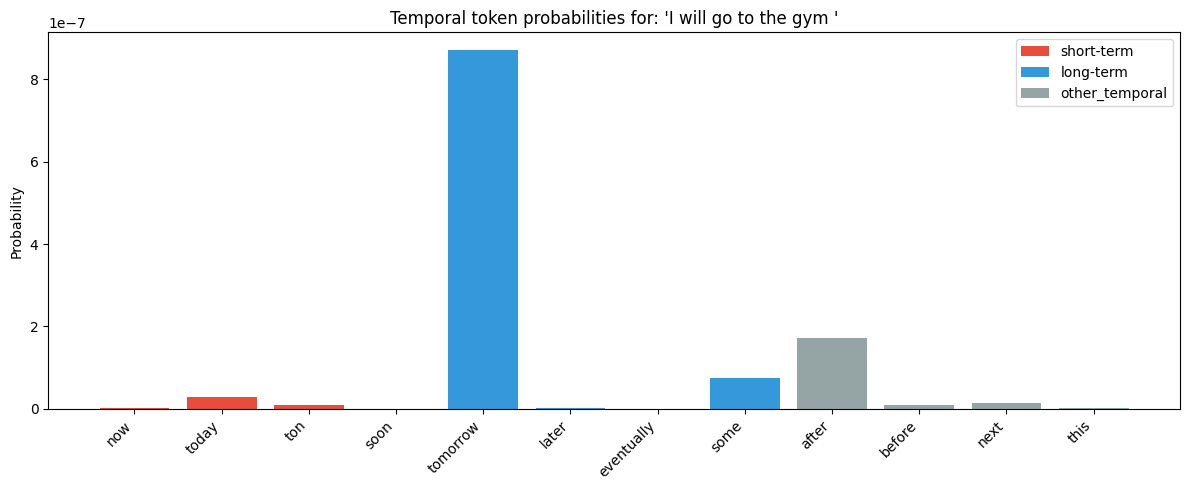

In [4]:
# Visualize temporal token probabilities
fig, ax = plt.subplots(figsize=(12, 5))

all_labels = []
all_probs = []
all_colors = []
color_map = {"short-term": "#e74c3c", "long-term": "#3498db", "other_temporal": "#95a5a6"}

for category, tokens in temporal_tokens.items():
    for tok in tokens:
        token_ids = model.tokenizer.encode(tok, add_special_tokens=False)
        tid = token_ids[0]
        p = probs[tid].item()
        decoded = model.tokenizer.decode(tid)
        all_labels.append(decoded.strip())
        all_probs.append(p)
        all_colors.append(color_map[category])

bars = ax.bar(range(len(all_labels)), all_probs, color=all_colors)
ax.set_xticks(range(len(all_labels)))
ax.set_xticklabels(all_labels, rotation=45, ha="right")
ax.set_ylabel("Probability")
ax.set_title(f"Temporal token probabilities for: '{prompt}'")

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in color_map.items()]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

## 3. Generate Attribution Graphs

We generate attribution graphs for the prompt. The graph captures which features contribute to which logit outputs. We can then compare which features are important for short-term vs long-term temporal tokens.

In [5]:
print("Generating attribution graph...")
# Use small batch_size and offload to CPU to avoid OOM on 12GB GPU
graph = attribute(prompt, model, batch_size=64, offload="cpu", verbose=True)

Phase 0: Precomputing activations and vectors


Generating attribution graph...


Precomputation completed in 0.17s


Found 5469 active features


Phase 1: Running forward pass


...

Feature influence computation:  73%|███████▎  | 3968/5469 [00:00<00:00, 9662.32it/s] 

Feature influence computation:  95%|█████████▍| 5184/5469 [00:00<00:00, 6446.93it/s]

Feature influence computation: 100%|██████████| 5469/5469 [00:00<00:00, 6954.18it/s]


Feature attributions completed in 0.79s


Attribution completed in 3.39s


In [6]:
# Examine the graph structure
print(f"Input tokens: {graph.input_tokens}")
print(f"Logit token IDs: {graph.logit_tokens}")
logit_token_strs = [model.tokenizer.decode(tok) for tok in graph.logit_tokens]
print(f"Logit tokens (decoded): {logit_token_strs}")
print(f"Logit probabilities: {[f'{p:.4f}' for p in graph.logit_probabilities.tolist()]}")
print(f"Number of active features: {graph.active_features.shape[0]}")
print(f"Number of selected features: {graph.selected_features.shape[0]}")
print(f"Adjacency matrix shape: {graph.adjacency_matrix.shape}")

Input tokens: tensor([     2, 235285,    877,    871,    577,    573,  15185, 235248],
       device='cuda:0')
Logit token IDs: tensor([235304, 235284,    199, 235310, 235308, 235274,    201, 235318,    200,
        235324], device='cuda:0')
Logit tokens (decoded): ['3', '2', '<strong>', '4', '5', '1', '<b>', '6', '<em>', '7']
Logit probabilities: ['0.2812', '0.1709', '0.1035', '0.1035', '0.0913', '0.0630', '0.0554', '0.0297', '0.0181', '0.0181']
Number of active features: 5469
Number of selected features: 5469
Adjacency matrix shape: torch.Size([5695, 5695])


In [7]:
# Check which temporal tokens appear in the graph's logit outputs
print("Logit tokens in the attribution graph:")
logit_token_strs = [model.tokenizer.decode(tok) for tok in graph.logit_tokens]
for i, (tok_str, prob) in enumerate(zip(logit_token_strs, graph.logit_probabilities.tolist())):
    print(f"  {i}: {tok_str!r:15s} prob={prob:.4f}")

# Identify short-term vs long-term tokens in the logits
short_term_set = {"now", "today", "tonight", "soon"}
long_term_set = {"tomorrow", "later", "eventually", "someday"}

short_term_logit_idxs = []
long_term_logit_idxs = []
for i, tok_str in enumerate(logit_token_strs):
    tok_clean = tok_str.strip().lower()
    if tok_clean in short_term_set:
        short_term_logit_idxs.append(i)
        print(f"  -> SHORT-TERM logit: {tok_str!r} at index {i}")
    elif tok_clean in long_term_set:
        long_term_logit_idxs.append(i)
        print(f"  -> LONG-TERM logit: {tok_str!r} at index {i}")

print(f"\nShort-term logit indices: {short_term_logit_idxs}")
print(f"Long-term logit indices: {long_term_logit_idxs}")

Logit tokens in the attribution graph:
  0: '3'             prob=0.2812
  1: '2'             prob=0.1709
  2: '<strong>'      prob=0.1035
  3: '4'             prob=0.1035
  4: '5'             prob=0.0913
  5: '1'             prob=0.0630
  6: '<b>'           prob=0.0554
  7: '6'             prob=0.0297
  8: '<em>'          prob=0.0181
  9: '7'             prob=0.0181

Short-term logit indices: []
Long-term logit indices: []


## 4. Compare Circuits for Short-term vs Long-term

We analyze which features in the attribution graph contribute most to short-term vs long-term temporal logits, and check whether they overlap or diverge.

In [8]:
# The adjacency matrix has shape (n_selected_features + n_error + n_tokens, n_selected_features + n_error + n_tokens + n_logits)
# The last n_logits columns correspond to the logit nodes
adj = graph.adjacency_matrix.float()
n_logits = len(graph.logit_tokens)
n_nodes = adj.shape[0]

# Feature -> logit contributions (last n_logits columns)
feature_to_logit = adj[:, -n_logits:]

print(f"Feature-to-logit matrix shape: {feature_to_logit.shape}")
print(f"  {feature_to_logit.shape[0]} source nodes -> {n_logits} logit targets")

Feature-to-logit matrix shape: torch.Size([5695, 10])
  5695 source nodes -> 10 logit targets


In [9]:
def get_top_features_for_logits(feature_to_logit, logit_indices, graph, k=20):
    """Get the top-k features contributing to the specified logit indices."""
    if not logit_indices:
        return [], []
    # Sum contributions across the target logits
    contrib = feature_to_logit[:, logit_indices].sum(dim=1)
    top_vals, top_idxs = contrib.abs().topk(min(k, len(contrib)))
    
    results = []
    for val, idx in zip(top_vals, top_idxs):
        idx = idx.item()
        # Get actual contribution (signed)
        actual_val = contrib[idx].item()
        results.append((idx, actual_val))
    return results

if short_term_logit_idxs:
    print("Top features contributing to SHORT-TERM logits:")
    short_features = get_top_features_for_logits(feature_to_logit, short_term_logit_idxs, graph, k=20)
    for node_idx, val in short_features:
        print(f"  Node {node_idx:4d}: contribution = {val:+.4f}")
else:
    print("No short-term temporal tokens in graph logits.")
    short_features = []

print()

if long_term_logit_idxs:
    print("Top features contributing to LONG-TERM logits:")
    long_features = get_top_features_for_logits(feature_to_logit, long_term_logit_idxs, graph, k=20)
    for node_idx, val in long_features:
        print(f"  Node {node_idx:4d}: contribution = {val:+.4f}")
else:
    print("No long-term temporal tokens in graph logits.")
    long_features = []

No short-term temporal tokens in graph logits.

No long-term temporal tokens in graph logits.


In [10]:
# Compare circuit overlap
if short_features and long_features:
    short_set = set(idx for idx, _ in short_features)
    long_set = set(idx for idx, _ in long_features)
    shared = short_set & long_set
    short_only = short_set - long_set
    long_only = long_set - short_set
    
    print(f"Top-20 feature overlap analysis:")
    print(f"  Shared features:     {len(shared):3d} ({len(shared)/max(len(short_set|long_set),1)*100:.0f}%)")
    print(f"  Short-term only:     {len(short_only):3d}")
    print(f"  Long-term only:      {len(long_only):3d}")
    print(f"  Jaccard similarity:  {len(shared)/max(len(short_set|long_set),1):.3f}")
    
    if shared:
        print(f"\n  Shared feature nodes: {sorted(shared)}")
    if short_only:
        print(f"  Short-term unique:    {sorted(short_only)}")
    if long_only:
        print(f"  Long-term unique:     {sorted(long_only)}")
else:
    print("Cannot compare - need both short-term and long-term logits in the graph.")
    print("Trying alternative approach: compare feature contributions to ALL logits.")

Cannot compare - need both short-term and long-term logits in the graph.
Trying alternative approach: compare feature contributions to ALL logits.


## 5. Alternative: Direct Logit Attribution for Specific Tokens

Even if the temporal tokens don't appear in the graph's top logits, we can use the model's activations and the unembedding matrix to compute which features push toward specific temporal tokens.

In [11]:
# Free GPU memory from attribution graph computation before getting activations
torch.cuda.empty_cache()

# Get activations from the model
logits_out, activation_cache = model.get_activations(prompt)

print(f"Logits shape: {logits_out.shape}")
print(f"Activation cache shape: {activation_cache.shape}")

Logits shape: torch.Size([1, 8, 256000])
Activation cache shape: torch.Size([26, 8, 16384])


In [12]:
# Get the unembedding matrix to project features into token space
W_U = model.W_U  # (d_model, vocab_size)
print(f"Unembedding matrix shape: {W_U.shape}")

# Get temporal token IDs
short_term_words = ["now", "today", "tonight", "soon"]
long_term_words = ["tomorrow", "later", "eventually", "someday"]

short_term_ids = [model.tokenizer.encode(w, add_special_tokens=False)[0] for w in short_term_words]
long_term_ids = [model.tokenizer.encode(w, add_special_tokens=False)[0] for w in long_term_words]

print(f"\nShort-term token IDs: {list(zip(short_term_words, short_term_ids))}")
print(f"Long-term token IDs: {list(zip(long_term_words, long_term_ids))}")

Unembedding matrix shape: torch.Size([2304, 256000])

Short-term token IDs: [('now', 1032), ('today', 23857), ('tonight', 1166), ('soon', 81158)]
Long-term token IDs: [('tomorrow', 122610), ('later', 20427), ('eventually', 174156), ('someday', 9041)]


In [13]:
# Use setup_attribution to get decoder vectors for active features
attr_ctx = model.setup_attribution(prompt)

print(f"Activation matrix shape: {attr_ctx.activation_matrix.shape}")
print(f"Decoder vecs shape: {attr_ctx.decoder_vecs.shape}")
print(f"Decoder locations shape: {attr_ctx.decoder_locations.shape}")
print(f"Note: decoder_vecs are already scaled by activation values")

Activation matrix shape: torch.Size([26, 8, 16384])
Decoder vecs shape: torch.Size([5469, 2304])
Decoder locations shape: torch.Size([2, 5469])
Note: decoder_vecs are already scaled by activation values


In [14]:
# Get the last token position
n_layers = attr_ctx.activation_matrix.shape[0]
last_pos = attr_ctx.activation_matrix.shape[1] - 1

print(f"Number of layers: {n_layers}, last position: {last_pos}")

# Move unembedding matrix to CPU for analysis to avoid GPU OOM
W_U_float = model.W_U.cpu().float()

# Directions for short-term and long-term
short_direction = W_U_float[:, short_term_ids].mean(dim=1)  # (d_model,)
long_direction = W_U_float[:, long_term_ids].mean(dim=1)    # (d_model,)

print(f"Cosine similarity between short and long unembed directions: {F.cosine_similarity(short_direction.unsqueeze(0), long_direction.unsqueeze(0)).item():.4f}")

Number of layers: 26, last position: 7


Cosine similarity between short and long unembed directions: 0.4555


In [15]:
# Compute per-feature contributions along the temporal directions
# decoder_vecs: (n_active_features, d_model) - already scaled by activations
# decoder_locations: (2, n_active_features) - [0]=layer_idx, [1]=pos_idx

decoder_vecs_cpu = attr_ctx.decoder_vecs.cpu().float()
decoder_locs = attr_ctx.decoder_locations.cpu()
layer_indices = decoder_locs[0]  # (n_features,)
pos_indices = decoder_locs[1]    # (n_features,)

# Filter to features at the last position
last_pos_mask = pos_indices == last_pos
last_pos_decoder_vecs = decoder_vecs_cpu[last_pos_mask]
last_pos_layers = layer_indices[last_pos_mask]

print(f"Active features at last position: {last_pos_mask.sum().item()}")
print(f"Total active features: {decoder_vecs_cpu.shape[0]}")

# Compute contribution to short-term vs long-term tokens for each feature
# Since decoder_vecs are already activation-scaled, contribution = decoder_vec @ W_U[:, token_id]
short_contribs = (last_pos_decoder_vecs @ W_U_float[:, short_term_ids]).mean(dim=1)
long_contribs = (last_pos_decoder_vecs @ W_U_float[:, long_term_ids]).mean(dim=1)
temporal_diffs = short_contribs - long_contribs

short_scores = short_contribs.tolist()
long_scores = long_contribs.tolist()

# Build temporal_scores list: (layer, index_in_filtered_list, short_contrib, long_contrib, diff)
temporal_scores = []
for i in range(last_pos_layers.shape[0]):
    layer = last_pos_layers[i].item()
    sc = short_contribs[i].item()
    lc = long_contribs[i].item()
    diff = temporal_diffs[i].item()
    temporal_scores.append((layer, i, sc, lc, diff))

# Sort by absolute temporal difference
temporal_scores.sort(key=lambda x: abs(x[4]), reverse=True)

print(f"\nTop 20 features by temporal difference (short - long):")
print(f"{'Layer':>5} {'Idx':>5} {'Short':>10} {'Long':>10} {'Diff':>10} {'Bias':>6}")
print("-" * 52)
for layer, idx, sc, lc, diff in temporal_scores[:20]:
    direction = "SHORT" if diff > 0 else "LONG"
    print(f"{layer:5d} {idx:5d} {sc:+10.4f} {lc:+10.4f} {diff:+10.4f} {direction:>6}")

Active features at last position: 820
Total active features: 5469

Top 20 features by temporal difference (short - long):
Layer   Idx      Short       Long       Diff   Bias
----------------------------------------------------
   25   812    +7.9318   +18.8844   -10.9527   LONG
   25   807   -10.1241    -1.3960    -8.7281   LONG
   25   819    -3.9270    -9.7456    +5.8186  SHORT
   21   718    +1.4736    +6.9274    -5.4539   LONG
   24   767    +3.6956    +7.7034    -4.0078   LONG
   24   786   -15.9700   -11.9698    -4.0001   LONG
    0     1    -0.9805    +2.8096    -3.7901   LONG
   24   765    +5.6469    +8.8583    -3.2114   LONG
   25   808    +1.7133    +4.7134    -3.0000   LONG
   25   795    +1.8095    -0.7997    +2.6092  SHORT
   23   738    -0.2353    -2.6169    +2.3816  SHORT
   22   722    +1.4070    +3.6275    -2.2205   LONG
   20   703    +0.2184    -1.8435    +2.0619  SHORT
    0     3    +0.0937    +2.0352    -1.9416   LONG
   24   783    -1.8950    -3.7304    +1.8354 

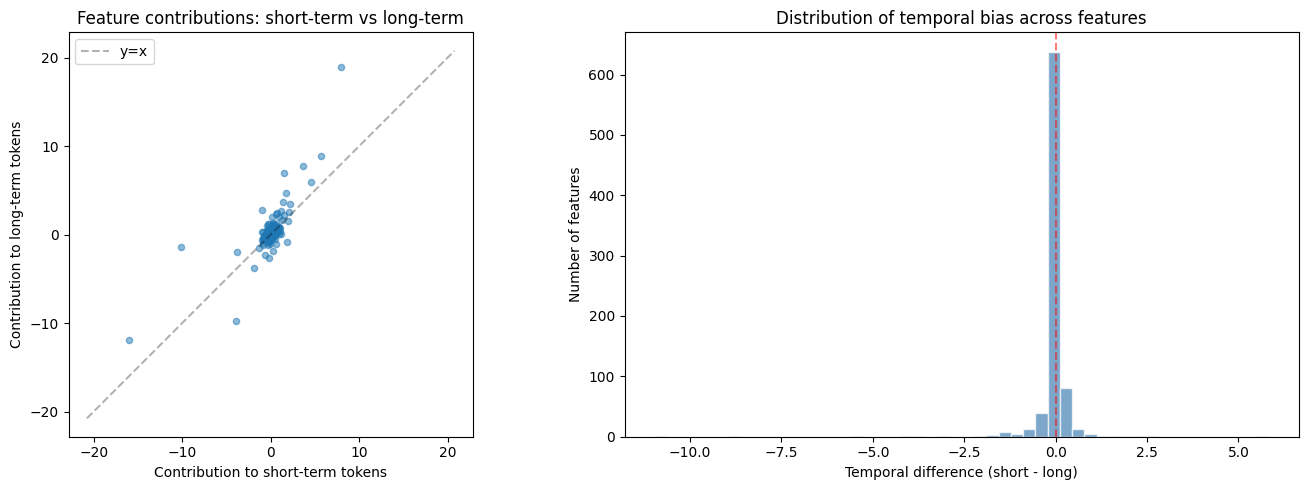

In [16]:
# Visualize the distribution of temporal biases across features
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Short vs Long contribution scatter
ax = axes[0]
ax.scatter(short_scores, long_scores, alpha=0.5, s=20)
max_val = max(max(abs(s) for s in short_scores), max(abs(s) for s in long_scores)) * 1.1
if max_val > 0:
    ax.plot([-max_val, max_val], [-max_val, max_val], 'k--', alpha=0.3, label='y=x')
ax.set_xlabel("Contribution to short-term tokens")
ax.set_ylabel("Contribution to long-term tokens")
ax.set_title("Feature contributions: short-term vs long-term")
ax.legend()
ax.set_aspect('equal')

# Plot 2: Temporal difference histogram
ax = axes[1]
diffs = [x[4] for x in temporal_scores]  # index 4 = diff
ax.hist(diffs, bins=50, alpha=0.7, color='steelblue', edgecolor='white')
ax.axvline(x=0, color='red', linestyle='--', alpha=0.5)
ax.set_xlabel("Temporal difference (short - long)")
ax.set_ylabel("Number of features")
ax.set_title("Distribution of temporal bias across features")

plt.tight_layout()
plt.show()

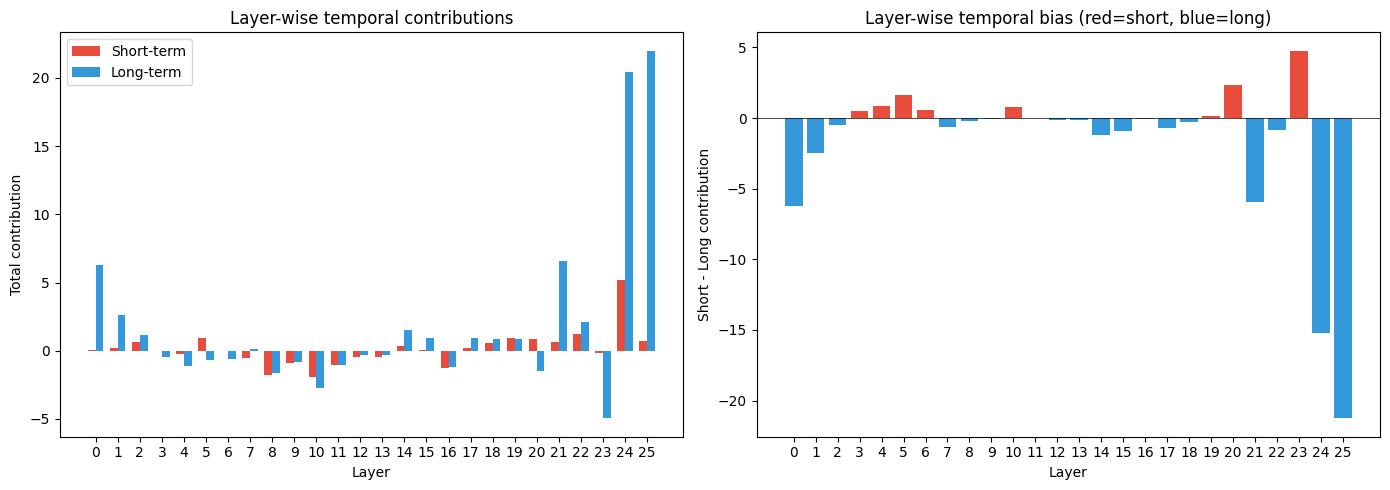


Layer-wise summary:
Layer      Short       Long       Diff     Bias
------------------------------------------------
    0    +0.0794    +6.2788    -6.1993     LONG
    1    +0.1905    +2.6449    -2.4543     LONG
    2    +0.6355    +1.1290    -0.4936     LONG
    3    -0.0034    -0.4858    +0.4824    SHORT
    4    -0.2565    -1.1406    +0.8842    SHORT
    5    +0.9506    -0.7104    +1.6610    SHORT
    6    -0.0254    -0.5809    +0.5555    SHORT
    7    -0.5383    +0.1105    -0.6488     LONG
    8    -1.8050    -1.6274    -0.1775     LONG
    9    -0.8917    -0.8218    -0.0699     LONG
   10    -1.9179    -2.7271    +0.8092    SHORT
   11    -1.0544    -1.0323    -0.0221     LONG
   12    -0.4453    -0.3084    -0.1369     LONG
   13    -0.4593    -0.2890    -0.1703     LONG
   14    +0.3253    +1.5264    -1.2011     LONG
   15    +0.0758    +0.9634    -0.8876     LONG
   16    -1.2545    -1.1592    -0.0953     LONG
   17    +0.1701    +0.9052    -0.7351     LONG
   18    +0.5798  

In [17]:
# Layer-wise analysis: which layers contribute most to temporal distinctions?
layer_short = {}
layer_long = {}

for layer, idx, sc, lc, diff in temporal_scores:
    layer_short[layer] = layer_short.get(layer, 0) + sc
    layer_long[layer] = layer_long.get(layer, 0) + lc

layers_list = sorted(set(layer_short.keys()) | set(layer_long.keys()))
short_by_layer = [layer_short.get(l, 0) for l in layers_list]
long_by_layer = [layer_long.get(l, 0) for l in layers_list]
diff_by_layer = [s - l for s, l in zip(short_by_layer, long_by_layer)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
x = np.arange(len(layers_list))
width = 0.35
ax.bar(x - width/2, short_by_layer, width, label='Short-term', color='#e74c3c')
ax.bar(x + width/2, long_by_layer, width, label='Long-term', color='#3498db')
ax.set_xticks(x)
ax.set_xticklabels(layers_list)
ax.set_xlabel('Layer')
ax.set_ylabel('Total contribution')
ax.set_title('Layer-wise temporal contributions')
ax.legend()

ax = axes[1]
colors = ['#e74c3c' if d > 0 else '#3498db' for d in diff_by_layer]
ax.bar(x, diff_by_layer, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(layers_list)
ax.set_xlabel('Layer')
ax.set_ylabel('Short - Long contribution')
ax.set_title('Layer-wise temporal bias (red=short, blue=long)')
ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f"\nLayer-wise summary:")
print(f"{'Layer':>5} {'Short':>10} {'Long':>10} {'Diff':>10} {'Bias':>8}")
print("-" * 48)
for l, s, lo, d in zip(layers_list, short_by_layer, long_by_layer, diff_by_layer):
    bias = "SHORT" if d > 0 else "LONG"
    print(f"{l:5d} {s:+10.4f} {lo:+10.4f} {d:+10.4f} {bias:>8}")

## 6. Circuit Graph Visualization

We construct supernodes from the top temporal features and visualize the circuit as in the tutorial notebook. We group the top features into interpretable supernodes based on their temporal bias and layer.

Baseline circuit visualization:
Top outputs: [('3', '0.281'), ('2', '0.171'), ('4', '0.104'), ('<strong>', '0.104'), ('5', '0.091')]


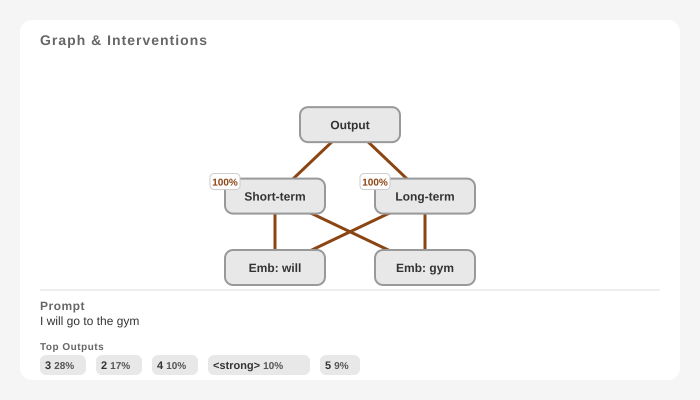

In [18]:
# Build supernodes from top temporal features
# We need (layer, feature_idx, activation) for each feature
act_sparse = attr_ctx.activation_matrix[:, last_pos, :]
if act_sparse.is_sparse:
    act_dense = act_sparse.to_dense().cpu().float()
else:
    act_dense = act_sparse.cpu().float()

# Map from filtered index to (layer, feat_idx, act_val)
feature_info_map = []
for layer_idx in range(n_layers):
    layer_acts = act_dense[layer_idx]
    nonzero_feats = layer_acts.nonzero(as_tuple=True)[0]
    for fi in nonzero_feats:
        act_val = layer_acts[fi.item()].item()
        feature_info_map.append((layer_idx, fi.item(), act_val))

# Get top 5 short-favoring and top 5 long-favoring features
top_short = [(feature_info_map[ts[1]], ts) for ts in temporal_scores if ts[4] > 0][:5]
top_long = [(feature_info_map[ts[1]], ts) for ts in temporal_scores if ts[4] < 0][:5]

# Create Feature objects for supernodes
short_term_features = [Feature(layer=info[0], pos=last_pos, feature_idx=info[1]) for info, _ in top_short]
long_term_features = [Feature(layer=info[0], pos=last_pos, feature_idx=info[1]) for info, _ in top_long]

# Create output node (represents the model's temporal prediction)
output_node = Supernode(name="Output", features=[], children=[])

# Create temporal supernodes
short_node = Supernode(
    name="Short-term",
    features=short_term_features,
    children=[output_node]
)
long_node = Supernode(
    name="Long-term",
    features=long_term_features,
    children=[output_node]
)

# Create input embedding nodes (represent prompt tokens contributing to temporal features)
# "will" and "gym" are likely the most relevant tokens for temporal reasoning
will_emb = Supernode(name="Emb: will", features=None, children=[short_node, long_node])
gym_emb = Supernode(name="Emb: gym", features=None, children=[short_node, long_node])

# Define ordered nodes (bottom to top: embeddings -> temporal features -> output)
ordered_nodes = [
    [will_emb, gym_emb],       # Bottom: input embeddings
    [short_node, long_node],    # Middle: temporal feature groups
    [output_node],              # Top: output
]

# Create the intervention graph
temporal_graph = InterventionGraph(ordered_nodes=ordered_nodes, prompt=prompt)

# Get activations and initialize nodes
logits_viz, activations_viz = model.get_activations(prompt)

for node in [will_emb, gym_emb, short_node, long_node, output_node]:
    temporal_graph.initialize_node(node, activations_viz)

temporal_graph.set_node_activation_fractions(activations_viz)

# Helper: get top outputs
def get_top_outputs(logits_tensor, k=5):
    top_probs, top_token_ids = logits_tensor.squeeze(0)[-1].softmax(-1).topk(k)
    top_tokens = [model.tokenizer.decode(token_id) for token_id in top_token_ids]
    return list(zip(top_tokens, top_probs.tolist()))

top_outputs = get_top_outputs(logits_viz)

print("Baseline circuit visualization:")
print(f"Top outputs: {[(t, f'{p:.3f}') for t, p in top_outputs]}")
create_graph_visualization(temporal_graph, top_outputs)

In [19]:
# Supernode intervention helper (same pattern as tutorial)
Intervention = namedtuple("Intervention", ["supernode", "scaling_factor"])

def supernode_intervention(intervention_graph, interventions, replacements=None):
    """Perform interventions on supernodes and visualize the result."""
    intervention_values = [
        (*feature, scaling_factor * default_act)
        for intervened_supernode, scaling_factor in interventions
        for feature, default_act in zip(
            intervened_supernode.features, intervened_supernode.default_activations
        )
    ]
    new_logits, new_activations = model.feature_intervention(
        intervention_graph.prompt, intervention_values
    )
    intervention_graph.set_node_activation_fractions(new_activations)
    top_outputs = get_top_outputs(new_logits)

    for intervened_supernode, scaling_factor in interventions:
        intervened_supernode.activation = None
        intervened_supernode.intervention = f"{scaling_factor}x"

    if replacements is not None:
        for target, replacement in replacements.items():
            intervention_graph.nodes[target].replacement_node = replacement

    return create_graph_visualization(intervention_graph, top_outputs)

Ablating short-term supernode (-2x):


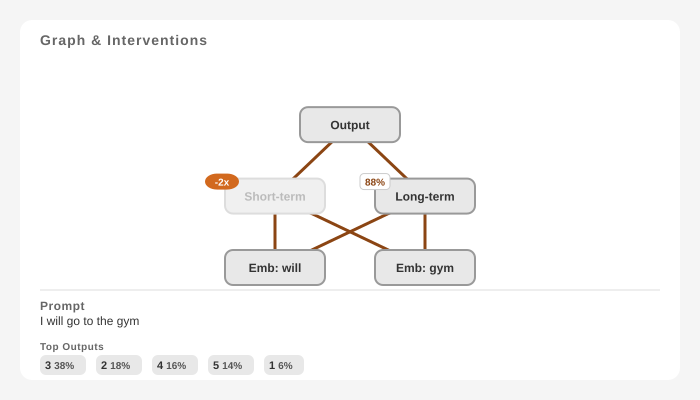

In [20]:
# Intervention 1: Ablate short-term features (-2x)
# This should shift the model away from short-term temporal predictions
print("Ablating short-term supernode (-2x):")
supernode_intervention(temporal_graph, [Intervention(short_node, -2)])

Ablating long-term supernode (-2x):


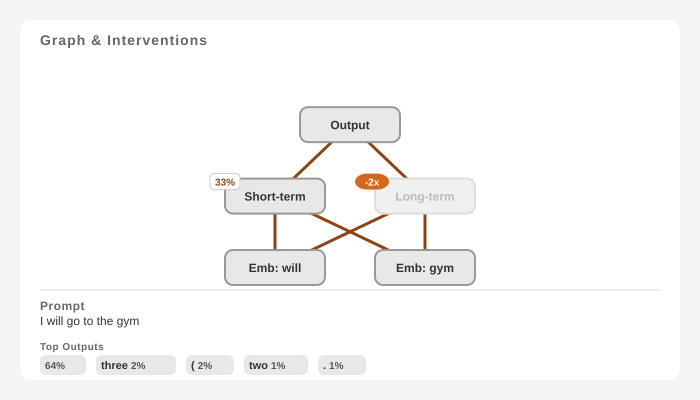

In [21]:
# Intervention 2: Ablate long-term features (-2x)
# This should shift the model away from long-term temporal predictions
print("Ablating long-term supernode (-2x):")
supernode_intervention(temporal_graph, [Intervention(long_node, -2)])

Ablating both short-term and long-term supernodes (-2x each):


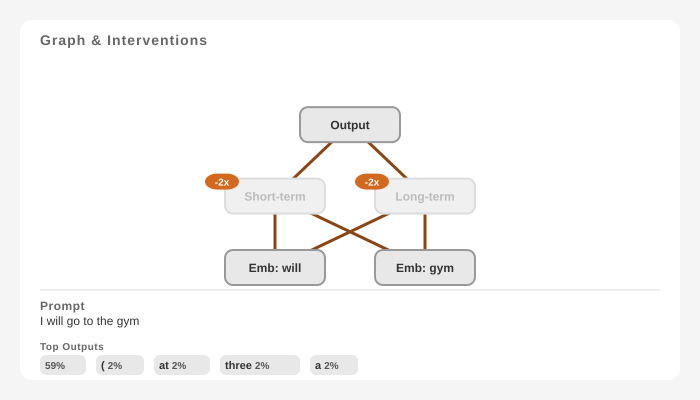

In [22]:
# Intervention 3: Ablate both temporal supernodes
print("Ablating both short-term and long-term supernodes (-2x each):")
supernode_intervention(temporal_graph, [
    Intervention(short_node, -2),
    Intervention(long_node, -2)
])

Boosting short-term supernode (2x):


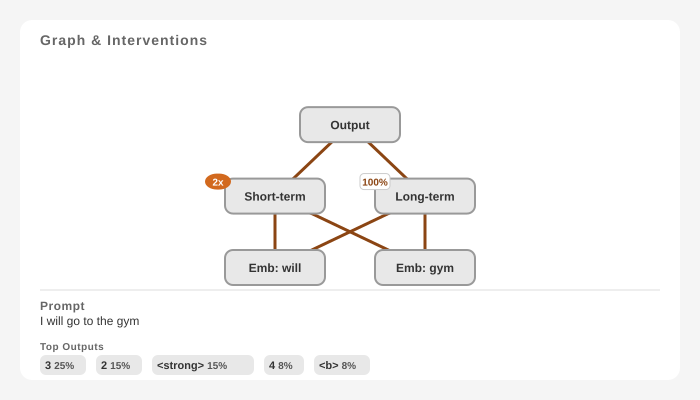

In [23]:
# Intervention 4: Boost short-term features (2x)
print("Boosting short-term supernode (2x):")
supernode_intervention(temporal_graph, [Intervention(short_node, 2)])

Boosting long-term supernode (2x):


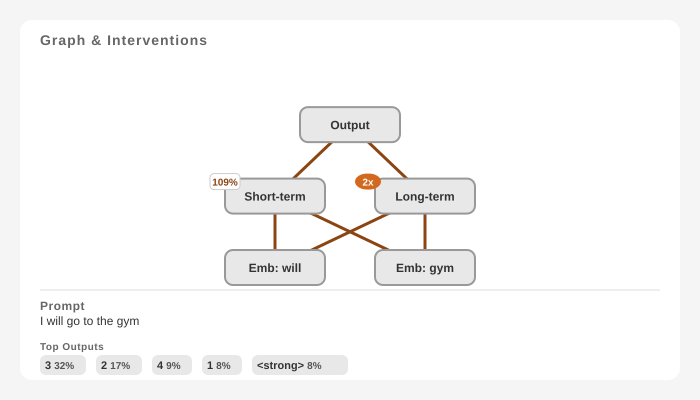

In [24]:
# Intervention 5: Boost long-term features (2x)
print("Boosting long-term supernode (2x):")
supernode_intervention(temporal_graph, [Intervention(long_node, 2)])